In [37]:
%pip install gymnasium numpy imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import gymnasium as gym
import numpy as np
import imageio
from IPython.display import Image, display

print("Everything is ready!")


Everything is ready!


In [39]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True,
    render_mode="rgb_array"
)

print("Environment created!")
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)


Environment created!
Number of states: 16
Number of actions: 4


In [40]:
%pip install pygame

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


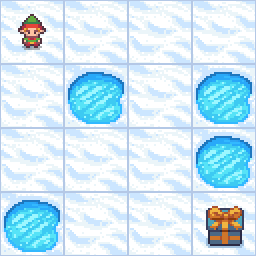

In [41]:
state, info = env.reset()

frame = env.render()

display(Image(data=imageio.v3.imwrite("<bytes>", frame, extension=".png")))

In [42]:
q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

print("Q-table shape:", q_table.shape)

Q-table shape: (16, 4)


In [43]:
alpha = 0.8
gamma = 0.95

epsilon = 1.0
epsilon_decay = 0.001
min_epsilon = 0.01

episodes = 10000

print("Training settings ready!")

Training settings ready!


In [44]:
for episode in range(episodes):

    state, info = env.reset()
    done = False

    while not done:

        # Explore
        if np.random.random() < epsilon:
            action = env.action_space.sample()

        # Use what the agent has learned
        else:
            action = np.argmax(q_table[state])

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Update Q-table
        q_table[state, action] = q_table[state, action] + alpha * (
            reward
            + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state

    # Reduce exploration
    epsilon = max(
        min_epsilon,
        epsilon - epsilon_decay
    )

print("🎉 Training completed!")

🎉 Training completed!


In [45]:
np.set_printoptions(precision=2, suppress=True)

print(q_table)

[[0.04 0.02 0.05 0.05]
 [0.01 0.   0.   0.03]
 [0.03 0.02 0.45 0.01]
 [0.   0.   0.01 0.03]
 [0.05 0.   0.02 0.01]
 [0.   0.   0.   0.  ]
 [0.   0.   0.12 0.  ]
 [0.   0.   0.   0.  ]
 [0.02 0.02 0.02 0.04]
 [0.01 0.01 0.01 0.  ]
 [0.   0.91 0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.09 0.11 0.34 0.1 ]
 [0.22 0.34 0.99 0.2 ]
 [0.   0.   0.   0.  ]]


In [46]:
gif_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True,
    render_mode="rgb_array"
)

state, info = gif_env.reset()

frames = []

# Save starting frame
frames.append(gif_env.render())

done = False

while not done:

    # Choose the best action learned by the agent
    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = gif_env.step(action)

    # Save Gymnasium's actual rendered frame
    frames.append(gif_env.render())

    done = terminated or truncated

gif_env.close()

print("Frames recorded:", len(frames))

Frames recorded: 20


In [47]:
imageio.mimsave(
    "frozenlake.gif",
    frames,
    duration=0.5,
    loop=0
)

print("🎬 GIF created successfully!")

🎬 GIF created successfully!


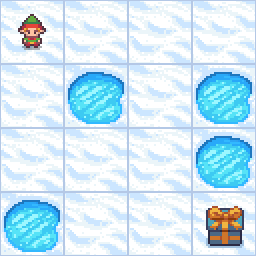

In [48]:
display(Image(filename="frozenlake.gif"))